In [ ]:

###############################################################################
#             Unidade 2: Modelos de regularizacao ou penalidade               #
#                         Secao 2.2: Regressao Ridge                          # 
###############################################################################

# Vamos evitar a notacao cientifica nos resultados
options(scipen = 999)

## Instala pacotes necessários (instala apenas os ausentes, sem prompt)
required_pkgs <- c("yarrr", "plyr", "readr", "dplyr", "caret", "ggplot2", "repr", "glmnet", "fastDummies", "tidyverse")
install_if_missing <- function(pkgs) {
  missing <- pkgs[!sapply(pkgs, requireNamespace, quietly = TRUE)]
  if(length(missing)) install.packages(missing, repos = "https://cloud.r-project.org")
}
install_if_missing(required_pkgs)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘prodlim’, ‘ipred’, ‘recipes’


Warning message in install.packages(missing, repos = "https://cloud.r-project.org"):
“installation of package ‘yarrr’ had non-zero exit status”
Warning message in install.packages(missing, repos = "https://cloud.r-project.org"):
“installation of package ‘glmnet’ had non-zero exit status”


Warning message in install.packages(missing, repos = "https://cloud.r-project.org"):
“installation of package ‘recipes’ had non-zero exit status”
Warning message in install.packages(missing, repos = "https://cloud.r-project.org"):
“installation of package ‘caret’ had non-zero exit status”


In [1]:
# Carregando os pacotes necessarios
library(plyr)
library(readr)
library(dplyr)
library(caret)
library(ggplot2)
library(repr)
library(glmnet)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:plyr’:

    arrange, count, desc, mutate, rename, summarise, summarize


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




ERROR: Error in library(caret): there is no package called ‘caret’


In [2]:
# Carrega o arquivo .RData e atribui o primeiro objeto carregado a 'dat'
loaded_names <- load("trabalhosalarios.RData")
dat <- get(loaded_names[1])
# Mostrar quais objetos foram carregados (debug)
print(loaded_names)

View(dat)

Warning message in readChar(con, 5L, useBytes = TRUE):
“cannot open compressed file 'trabalhosalarios.RData', probable reason 'No such file or directory'”


ERROR: Error in readChar(con, 5L, useBytes = TRUE): cannot open the connection


In [4]:
# Vamos visualizar parte do dataset
glimpse(dat)

Rows: 2,574
Columns: 17
$ husage   <dbl> 56, 31, 33, 34, 42, 45, 33, 31, 31, 44, 45, 22, 66, 43, 26, 3…
$ husunion <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0…
$ husearns <dbl> 1500, 800, 950, 1000, 730, 1154, 1350, 769, 340, 750, 1200, 2…
$ huseduc  <dbl> 14, 17, 13, 14, 14, 16, 16, 18, 12, 12, 12, 12, 16, 12, 14, 1…
$ husblck  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ hushisp  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ hushrs   <dbl> 40, 40, 60, 50, 40, 38, 40, 55, 40, 40, 50, 40, 40, 50, 36, 5…
$ kidge6   <dbl> 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0…
$ earns    <dbl> 100, 480, 455, 102, 300, 425, 770, 125, 245, 539, 300, 299, 5…
$ age      <dbl> 49, 29, 30, 31, 41, 45, 32, 27, 30, 42, 42, 23, 55, 31, 27, 3…
$ black    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ educ     <dbl> 12, 14, 12, 12, 12, 18, 12, 14, 15, 12, 12, 13, 12, 12, 14, 1…
$ hispanic <dbl>

In [5]:
# Checar valores faltantes no dataset 'dat'
na_count <- sum(is.na(dat))

if (na_count > 0) {
  cat("Há", na_count, "valores faltantes\n")
  # Contagem de NA por coluna
  print(sapply(dat, function(x) sum(is.na(x))))
} else {
  cat("Não há valores faltantes\n")
}


Não há valores faltantes


In [6]:
library(fastDummies)

# Transformando colunas  em variaveis dummy (categóricas) 

#1. Transformar em colunas dummies ( “quebrar” a categoria em números 0/1 para o modelo enxergar.)
#Finalidade:
#deixar a variável utilizável por modelos que só aceitam números, como glmnet;
#evitar dar uma ordem falsa para categorias;
#representar cada categoria separadamente no modelo.

#2. Transformar em factor (usado no ElasticNet)
#informar ao R/caret que a variável é qualitativa;
#fazer com que a interface por fórmula trate essa coluna como categoria e gere a codificação apropriada internamente;
#preservar o significado categórico durante o ajuste, especialmente quando você usa train(..., method = "glmnet") com fórmula.

dat <- dummy_cols(dat, select_columns = c("husunion", "husblck", "hushisp", "kidge6", "black", "hispanic", "union", "kidlt6"), 
                        remove_most_frequent_dummy=FALSE, 
                        remove_selected_columns=TRUE)
str(dat)

'data.frame':	2574 obs. of  25 variables:
 $ husage    : num  56 31 33 34 42 45 33 31 31 44 ...
 $ husearns  : num  1500 800 950 1000 730 ...
 $ huseduc   : num  14 17 13 14 14 16 16 18 12 12 ...
 $ hushrs    : num  40 40 60 50 40 38 40 55 40 40 ...
 $ earns     : num  100 480 455 102 300 425 770 125 245 539 ...
 $ age       : num  49 29 30 31 41 45 32 27 30 42 ...
 $ educ      : num  12 14 12 12 12 18 12 14 15 12 ...
 $ exper     : num  31 9 12 13 23 21 14 7 9 24 ...
 $ lwage     : num  1.9 2.48 2.43 1.63 2.3 ...
 $ husunion_0: int  1 1 1 1 1 1 1 1 1 1 ...
 $ husunion_1: int  0 0 0 0 0 0 0 0 0 0 ...
 $ husblck_0 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ husblck_1 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hushisp_0 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hushisp_1 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ kidge6_0  : int  0 1 1 0 0 0 1 1 1 0 ...
 $ kidge6_1  : int  1 0 0 1 1 1 0 0 0 1 ...
 $ black_0   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ black_1   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hispanic_0: int  1 1 1 1 1 1 1 1 1 1 

In [7]:
# As colunas dummy precisam continuar numericas para o glmnet.
str(dat)


'data.frame':	2574 obs. of  25 variables:
 $ husage    : num  56 31 33 34 42 45 33 31 31 44 ...
 $ husearns  : num  1500 800 950 1000 730 ...
 $ huseduc   : num  14 17 13 14 14 16 16 18 12 12 ...
 $ hushrs    : num  40 40 60 50 40 38 40 55 40 40 ...
 $ earns     : num  100 480 455 102 300 425 770 125 245 539 ...
 $ age       : num  49 29 30 31 41 45 32 27 30 42 ...
 $ educ      : num  12 14 12 12 12 18 12 14 15 12 ...
 $ exper     : num  31 9 12 13 23 21 14 7 9 24 ...
 $ lwage     : num  1.9 2.48 2.43 1.63 2.3 ...
 $ husunion_0: int  1 1 1 1 1 1 1 1 1 1 ...
 $ husunion_1: int  0 0 0 0 0 0 0 0 0 0 ...
 $ husblck_0 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ husblck_1 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hushisp_0 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hushisp_1 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ kidge6_0  : int  0 1 1 0 0 0 1 1 1 0 ...
 $ kidge6_1  : int  1 0 0 1 1 1 0 0 0 1 ...
 $ black_0   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ black_1   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hispanic_0: int  1 1 1 1 1 1 1 1 1 1 

In [8]:
# Vamos jogar a semente para gerar numeros aleatorios
# Aqui no exemplo a semente eh "5", mas poderia
# ser qualquer outro numero, se todos usarem a mesma
# semente os resultados serao iguais.
# Essa semente de numeros aleatorios serve para
# particionar o dataset aleatoriamente
set.seed(5)  

# Vamos criar um indice para particionar o dataset em
# 50% para treinamento
index = sample(1:nrow(dat),0.5*nrow(dat))

# Vamos criar a base de dados de treinamento
train = dat[index,]  

# Vamos criar a base de dados de teste
test = dat[-index,] 

# Vamos checar as dimensoes das bases de treinamento e 
# teste
dim(train)
dim(test)
# A base de treinamento possui 75 linhas e 
# 10 colunas (variaveis)
# A base de teste possui 75 linhas e 10
# colunas (variaveis)

[1] 1287   25

[1] 1287   25

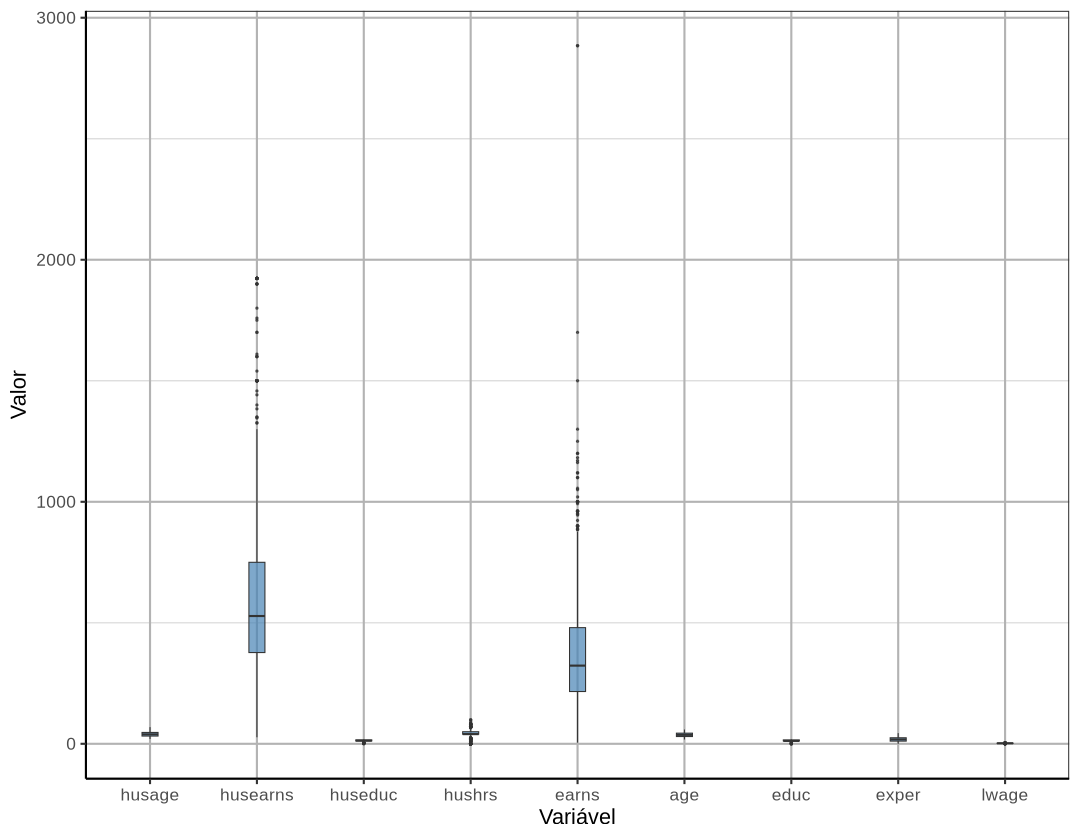

In [9]:
# Mostra um boxplot por variável para comparar escalas
# Facilita pra decidir se é necessário padronizar as variáveis

# Do enunciado, a variável dependente é "lwage" (log do salário), ou seja, já está padronizada

# Amplia só um pouco o tamanho do gráfico na saída do notebook
options(repr.plot.width = 9, repr.plot.height = 7)

train[, c("husage", "husearns", "huseduc", "hushrs", "earns", "age", "educ", "exper", "lwage")] %>%  # escolhe colunas
  stack() %>%  # coloca em formato longo (variável/valor)
  ggplot(aes(x = ind, y = values)) +  # inicia o gráfico
  geom_boxplot(fill = "steelblue", alpha = 0.7, width = 0.15, linewidth = 0.3, outlier.size = 0.3) +  # desenha boxplots
  labs(x = "Variável", y = "Valor") +  # rótulos dos eixos
  theme_bw(base_size = 13) +
  theme(
    axis.line = element_line(color = "black"),
    panel.grid.major = element_line(color = "grey70", linewidth = 0.6),
    panel.grid.minor = element_line(color = "grey85", linewidth = 0.35)
  )

In [10]:
# Padronizando com z-score apenas os preditores numéricos: husage, husearns, huseduc, hushrs, earns, age, educ, exper.

# incluir lwage na padronização?
# se padronizar , lembrar de no final despadronizar e fazer exp(lwage)
cols <- c("husage", "husearns", "huseduc", "hushrs", "earns", "age", "educ", "exper", "lwage")
pre_proc_val <- caret::preProcess(train[,cols], 
                           method = c("center", "scale")) # calcula média e desvio-padrão para cada coluna selecionada.

train1 <- train # necessário para criar uma cópia do dataset original e aplicar a padronização apenas nas colunas selecionadas, mantendo as outras colunas inalteradas.
train1[,cols] <- predict(pre_proc_val, train[,cols]) # realiza a padronização de fato nas colunas selecionadas

View(train1)


,husage,husearns,huseduc,hushrs,earns,age,educ,exper,lwage,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
834,-1.0045311,1.092371637,0.9553296,-0.9662236,1.15215688,-0.94595911,1.0858287,-1.18292507,1.1553088,1,⋯,1,0,1,0,1,0,1,0,0,1
2255,-0.6059703,-0.910693888,-0.5171365,0.5758520,-1.12709099,-0.62374048,-0.5827821,-0.45726989,-0.1521680,1,⋯,0,1,1,0,1,0,1,0,1,0
889,1.1875532,-1.153122393,-0.5171365,-0.1951858,-0.38520199,0.23550918,-0.5827821,0.37205031,-0.4911810,1,⋯,1,0,1,0,1,0,1,0,0,1
1833,1.2871934,-0.456140440,-1.9896026,-0.1951858,-0.55006621,1.30957126,-0.5827821,1.40870057,-0.7909113,0,⋯,1,0,1,0,1,0,1,0,1,0
1246,0.9882728,-0.256136924,-0.5171365,-0.1951858,-0.09668960,0.98735264,-0.5827821,1.09770550,0.2023359,0,⋯,1,0,0,1,1,0,0,1,1,0
1527,1.0879130,-0.486444004,-0.5171365,-0.1951858,-0.74790328,1.09475885,-0.5827821,1.20137052,-0.2315421,1,⋯,1,0,1,0,1,0,1,0,1,0
387,0.8886326,2.725733690,0.9553296,0.4216445,0.12999871,-0.30152186,-0.5827821,-0.14627482,0.2264911,1,⋯,0,1,1,0,1,0,0,1,1,0
826,0.7889924,-0.153104809,-0.5171365,0.1903331,1.63438473,0.77254022,-0.5827821,0.89037544,1.7354092,0,⋯,1,0,1,0,1,0,1,0,1,0
943,1.7853944,-0.486444004,-1.9896026,-0.1951858,1.03263032,0.66513402,-0.5827821,0.78671042,1.0669808,1,⋯,1,0,1,0,1,0,1,0,1,0


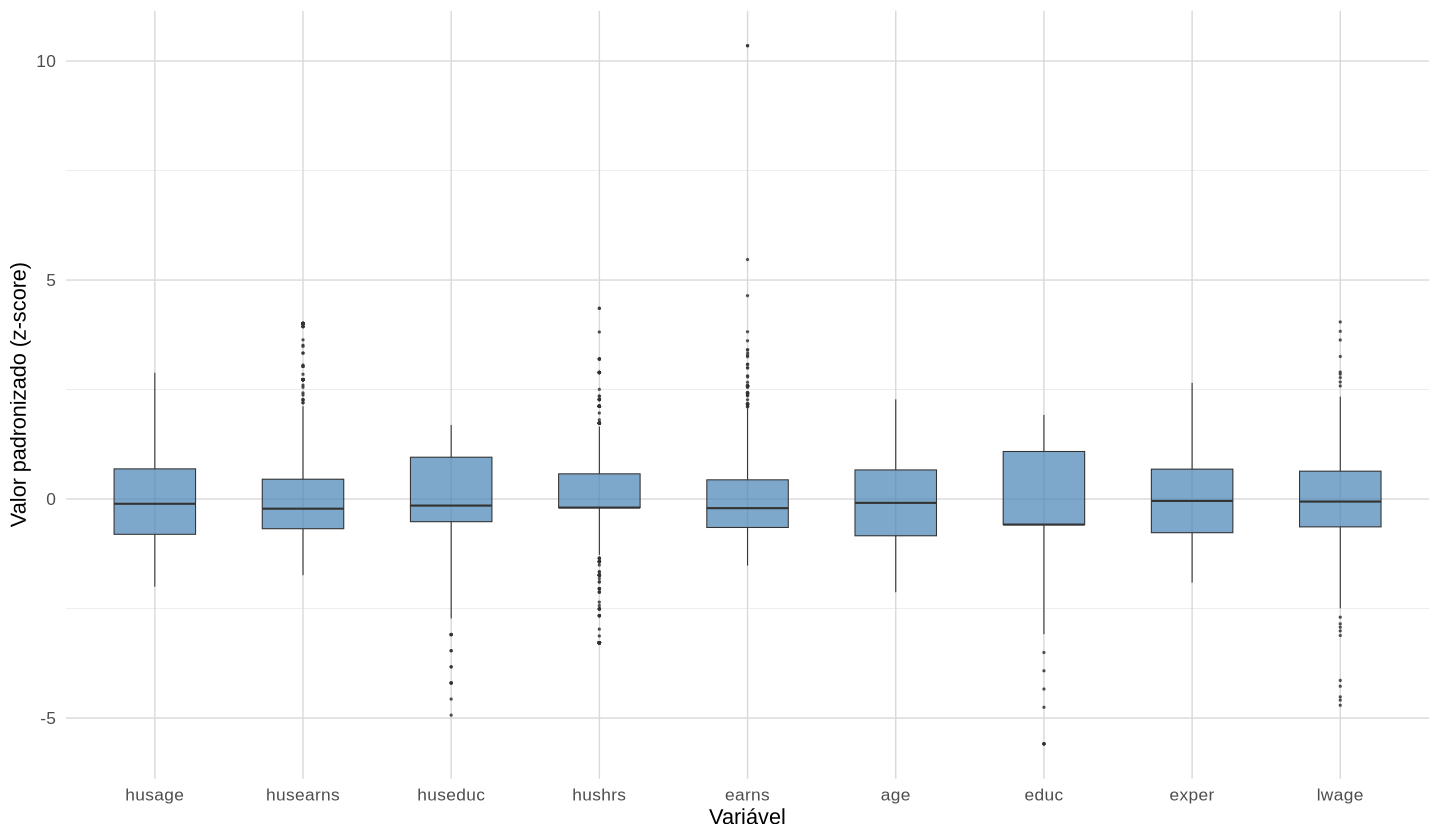

In [11]:
# Verificando os boxplots após a padronização, para confirmar que as variáveis numéricas estão na mesma escala.

 # Amplia só um pouco o tamanho do gráfico na saída do notebook
options(repr.plot.width = 12, repr.plot.height = 7)

train1[, c("husage", "husearns", "huseduc", "hushrs", "earns", "age", "educ", "exper", "lwage")] %>%  # escolhe colunas
  stack() %>%  # coloca em formato longo (variável/valor)
  ggplot(aes(x = ind, y = values)) +  # inicia o gráfico com um único eixo x e um único eixo y
  geom_boxplot(fill = "steelblue", alpha = 0.7, width = 0.55, linewidth = 0.3, outlier.size = 0.3) +  # desenha boxplots
  labs(x = "Variável", y = "Valor padronizado (z-score)") +  # rótulos dos eixos
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major = element_line(color = "grey85", linewidth = 0.4),
    panel.grid.minor = element_line(color = "grey92", linewidth = 0.25)
  )

In [12]:
# Padronizando a base de teste usando os parâmetros calculados na base de treino
test1 <- test
test1[,cols] <- predict(pre_proc_val, test[,cols]) # aplica centro e escala calculados em 'train'


View(test1)

,husage,husearns,huseduc,hushrs,earns,age,educ,exper,lwage,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1.586113988,2.725733690,0.2190965,-0.19518580,-1.12709099,1.20216506,-0.5827821,1.30503555,-0.586047966,1,⋯,0,1,1,0,1,0,1,0,1,0
2,-0.904890921,0.604484270,1.3234461,-0.19518580,0.43911912,-0.94595911,0.2515233,-0.97559502,0.556841747,1,⋯,1,0,1,0,1,0,1,0,1,0
4,-0.605970332,1.210555533,0.2190965,0.57585203,-1.11884778,-0.73114669,-0.5827821,-0.56093492,-1.106910376,1,⋯,0,1,1,0,1,0,1,0,1,0
8,-0.904890921,0.510543224,1.6915627,0.96137094,-1.02405085,-1.16077152,0.2515233,-1.18292507,-0.806404232,1,⋯,1,0,1,0,1,0,1,0,0,1
14,0.290791436,-0.607658256,-0.5171365,0.57585203,-0.46763410,-0.73114669,-0.5827821,-0.56093492,-0.635276142,1,⋯,0,1,1,0,1,0,1,0,1,0
15,-1.403091902,-0.244015498,0.2190965,-0.50360093,-0.11729763,-1.16077152,0.2515233,-1.18292507,-0.085278927,1,⋯,1,0,1,0,1,0,1,0,1,0
17,1.087913006,-0.304622625,-0.5171365,-0.19518580,-0.22033777,1.20216506,-0.5827821,1.30503555,-1.019927896,1,⋯,1,0,1,0,1,0,1,0,1,0
18,-0.207409546,2.725733690,0.9553296,-0.19518580,0.72763151,0.02069677,1.0858287,-0.24993984,0.821536037,1,⋯,1,0,1,0,1,0,1,0,0,1
19,-0.307049743,-0.410685096,-0.5171365,0.57585203,1.29229147,-0.62374048,1.5029814,-0.97559502,1.254000448,1,⋯,1,0,1,0,1,0,0,1,0,1


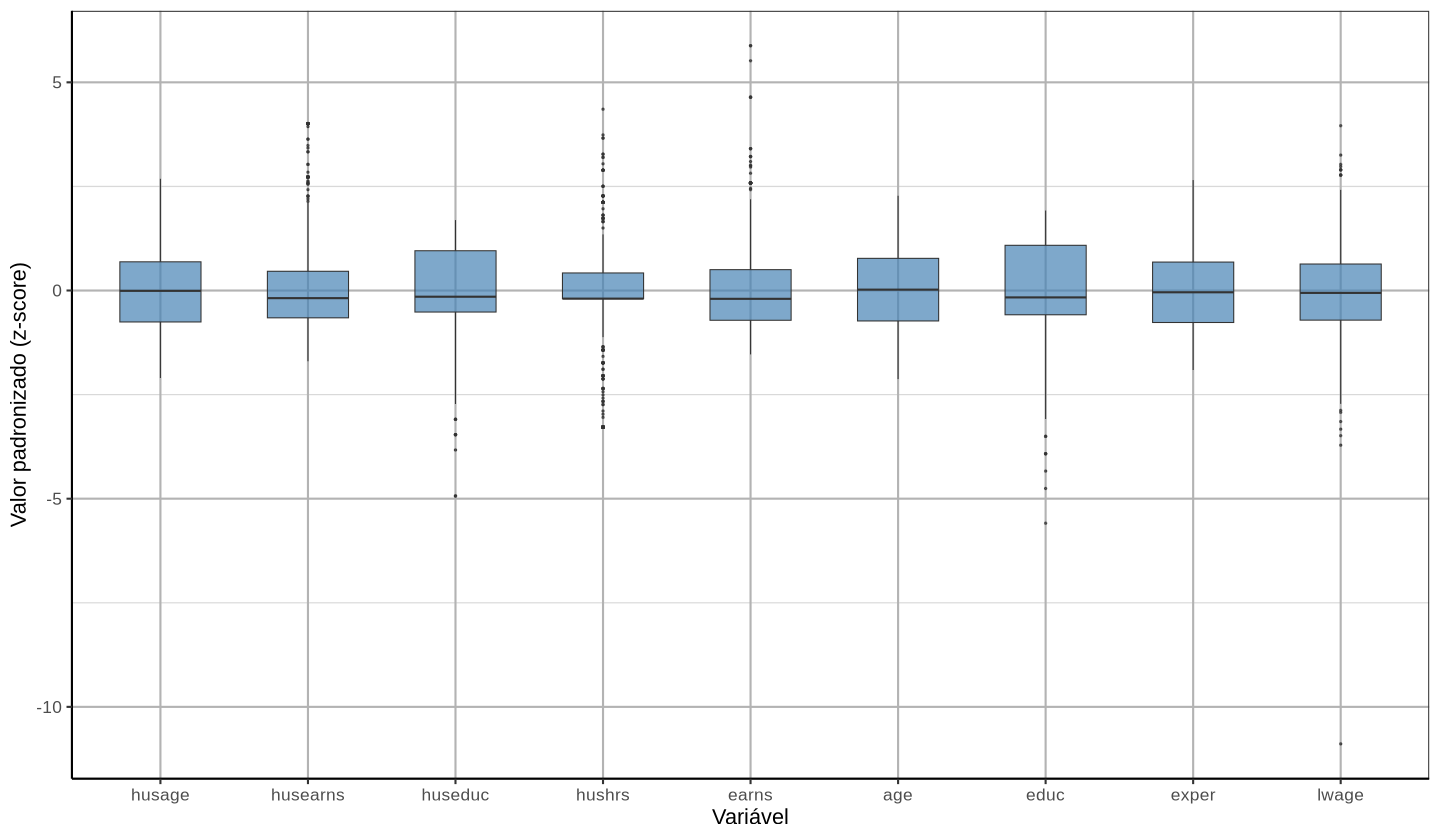

In [13]:
# Verificando os boxplots após a padronização, para confirmar que as variáveis numéricas estão na mesma escala.

 # Amplia só um pouco o tamanho do gráfico na saída do notebook
options(repr.plot.width = 12, repr.plot.height = 7)

test1[, c("husage", "husearns", "huseduc", "hushrs", "earns", "age", "educ", "exper", "lwage")] %>%  # escolhe colunas
  stack() %>%  # coloca em formato longo (variável/valor)
  ggplot(aes(x = ind, y = values)) +  # inicia o gráfico com um único eixo x e um único eixo y
  geom_boxplot(fill = "steelblue", alpha = 0.7, width = 0.55, linewidth = 0.3, outlier.size = 0.3) +  # desenha boxplots
  labs(x = "Variável", y = "Valor padronizado (z-score)") +  # rótulos dos eixos
  theme_bw(base_size = 13) +
  theme(
    axis.line = element_line(color = "black"),
    panel.grid.major = element_line(color = "grey70", linewidth = 0.6),
    panel.grid.minor = element_line(color = "grey85", linewidth = 0.35)
  )

In [14]:
###############################################################################
#                               REGRESSAO RIDGE                               #
###############################################################################

# A regressao Ridge "encolhe os valores dos coeficientes"

# Vamos guardar a matriz de dados de treinamento das 
# variaveis explicativas para o modelo em um objeto 
# chamado "x"
library(dplyr)

View(train1)

,husage,husearns,huseduc,hushrs,earns,age,educ,exper,lwage,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
834,-1.0045311,1.092371637,0.9553296,-0.9662236,1.15215688,-0.94595911,1.0858287,-1.18292507,1.1553088,1,⋯,1,0,1,0,1,0,1,0,0,1
2255,-0.6059703,-0.910693888,-0.5171365,0.5758520,-1.12709099,-0.62374048,-0.5827821,-0.45726989,-0.1521680,1,⋯,0,1,1,0,1,0,1,0,1,0
889,1.1875532,-1.153122393,-0.5171365,-0.1951858,-0.38520199,0.23550918,-0.5827821,0.37205031,-0.4911810,1,⋯,1,0,1,0,1,0,1,0,0,1
1833,1.2871934,-0.456140440,-1.9896026,-0.1951858,-0.55006621,1.30957126,-0.5827821,1.40870057,-0.7909113,0,⋯,1,0,1,0,1,0,1,0,1,0
1246,0.9882728,-0.256136924,-0.5171365,-0.1951858,-0.09668960,0.98735264,-0.5827821,1.09770550,0.2023359,0,⋯,1,0,0,1,1,0,0,1,1,0
1527,1.0879130,-0.486444004,-0.5171365,-0.1951858,-0.74790328,1.09475885,-0.5827821,1.20137052,-0.2315421,1,⋯,1,0,1,0,1,0,1,0,1,0
387,0.8886326,2.725733690,0.9553296,0.4216445,0.12999871,-0.30152186,-0.5827821,-0.14627482,0.2264911,1,⋯,0,1,1,0,1,0,0,1,1,0
826,0.7889924,-0.153104809,-0.5171365,0.1903331,1.63438473,0.77254022,-0.5827821,0.89037544,1.7354092,0,⋯,1,0,1,0,1,0,1,0,1,0
943,1.7853944,-0.486444004,-1.9896026,-0.1951858,1.03263032,0.66513402,-0.5827821,0.78671042,1.0669808,1,⋯,1,0,1,0,1,0,1,0,1,0


In [15]:
# reordenando o dataset porque a coluna "lwage" esta no meio do dataset
train1 <- train1 %>% select(lwage, everything()) # train1 é a base de treino padronizada
View(train1)


,lwage,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
834,1.1553088,-1.0045311,1.092371637,0.9553296,-0.9662236,1.15215688,-0.94595911,1.0858287,-1.18292507,1,⋯,1,0,1,0,1,0,1,0,0,1
2255,-0.1521680,-0.6059703,-0.910693888,-0.5171365,0.5758520,-1.12709099,-0.62374048,-0.5827821,-0.45726989,1,⋯,0,1,1,0,1,0,1,0,1,0
889,-0.4911810,1.1875532,-1.153122393,-0.5171365,-0.1951858,-0.38520199,0.23550918,-0.5827821,0.37205031,1,⋯,1,0,1,0,1,0,1,0,0,1
1833,-0.7909113,1.2871934,-0.456140440,-1.9896026,-0.1951858,-0.55006621,1.30957126,-0.5827821,1.40870057,0,⋯,1,0,1,0,1,0,1,0,1,0
1246,0.2023359,0.9882728,-0.256136924,-0.5171365,-0.1951858,-0.09668960,0.98735264,-0.5827821,1.09770550,0,⋯,1,0,0,1,1,0,0,1,1,0
1527,-0.2315421,1.0879130,-0.486444004,-0.5171365,-0.1951858,-0.74790328,1.09475885,-0.5827821,1.20137052,1,⋯,1,0,1,0,1,0,1,0,1,0
387,0.2264911,0.8886326,2.725733690,0.9553296,0.4216445,0.12999871,-0.30152186,-0.5827821,-0.14627482,1,⋯,0,1,1,0,1,0,0,1,1,0
826,1.7354092,0.7889924,-0.153104809,-0.5171365,0.1903331,1.63438473,0.77254022,-0.5827821,0.89037544,0,⋯,1,0,1,0,1,0,1,0,1,0
943,1.0669808,1.7853944,-0.486444004,-1.9896026,-0.1951858,1.03263032,0.66513402,-0.5827821,0.78671042,1,⋯,1,0,1,0,1,0,1,0,1,0


In [16]:

# Guardando os valores das variáveis explicativas em 'x'
# colunas 2 a última de train1 convertidas para uma matriz: é a matriz de preditores
x <- as.matrix(train1[,2:ncol(train1)])
ncol(train1)
View(x)

[1] 25

,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,husunion_1,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
834,-1.0045311,1.092371637,0.9553296,-0.9662236,1.15215688,-0.94595911,1.0858287,-1.18292507,1,0,⋯,1,0,1,0,1,0,1,0,0,1
2255,-0.6059703,-0.910693888,-0.5171365,0.5758520,-1.12709099,-0.62374048,-0.5827821,-0.45726989,1,0,⋯,0,1,1,0,1,0,1,0,1,0
889,1.1875532,-1.153122393,-0.5171365,-0.1951858,-0.38520199,0.23550918,-0.5827821,0.37205031,1,0,⋯,1,0,1,0,1,0,1,0,0,1
1833,1.2871934,-0.456140440,-1.9896026,-0.1951858,-0.55006621,1.30957126,-0.5827821,1.40870057,0,1,⋯,1,0,1,0,1,0,1,0,1,0
1246,0.9882728,-0.256136924,-0.5171365,-0.1951858,-0.09668960,0.98735264,-0.5827821,1.09770550,0,1,⋯,1,0,0,1,1,0,0,1,1,0
1527,1.0879130,-0.486444004,-0.5171365,-0.1951858,-0.74790328,1.09475885,-0.5827821,1.20137052,1,0,⋯,1,0,1,0,1,0,1,0,1,0
387,0.8886326,2.725733690,0.9553296,0.4216445,0.12999871,-0.30152186,-0.5827821,-0.14627482,1,0,⋯,0,1,1,0,1,0,0,1,1,0
826,0.7889924,-0.153104809,-0.5171365,0.1903331,1.63438473,0.77254022,-0.5827821,0.89037544,0,1,⋯,1,0,1,0,1,0,1,0,1,0
943,1.7853944,-0.486444004,-1.9896026,-0.1951858,1.03263032,0.66513402,-0.5827821,0.78671042,1,0,⋯,1,0,1,0,1,0,1,0,1,0
821,0.8886326,-0.910693888,-0.5171365,-0.1951858,-0.98283479,1.52438368,-0.5827821,1.61603062,1,0,⋯,1,0,0,1,1,0,1,0,1,0


In [17]:
# Vamos guardar o vetor de dados de treinamento da 
# variavel dependente para o modelo em um objeto
# chamado "y_train"
y_train = train1$lwage
View(y_train)

[1]  1.155308824 -0.152168036 -0.491180966 -0.790911298  0.202335883
   [6] -0.231542102  0.226491094  1.735409152  1.066980823 -1.475765870
  [11]  0.202335883  0.202335883 -1.445145548 -1.350278549  1.345225597
  [16] -0.673032391 -0.357031368  0.576991506 -1.219731913  0.990719733
  [21]  1.345225597  0.310385877 -0.960094993  0.376576949 -1.461416240
  [26] -0.357031368  0.216864398  0.636215813 -1.508581414  0.738475400
  [31] -0.625330565  0.984227400  1.701979181 -0.357031368  0.202335883
  [36]  3.828516600 -0.357031368 -2.493166318  0.061229242 -0.547543125
  [41]  0.767769645 -0.231542102  1.667965891  0.202335883 -0.125137066
  [46]  0.202335883  1.195583064 -0.299557016 -0.491180966  1.250358597
  [51]  0.422692149 -1.423659991 -1.461416240  0.287922289  0.636215813
  [56] -0.563951869 -0.357031368  0.387656107 -0.491180966  0.092341496
  [61] -0.411806901  1.246753690  0.040208395  1.701979181  0.452838039
  [66] -1.445145548 -0.011187781 -0.451898368  0.253506509  1.345225597
  [71] -0.357031368  0.102602065 -0.090923504  1.699729516  0.387656107
  [76]  0.636215813 -0.703775210 -0.689880568 -1.050548218  1.234085961
  [81]  1.983966914 -1.319656282  0.202335883 -3.009797726 -0.711535288
  [86]  0.058240708  1.100957170 -0.790911298  0.439975870 -1.050548218
  [91]  0.076848562  0.486728832  0.452838039  0.636215813  0.474088324
  [96]  0.353693372 -0.505118385 -0.231542102  0.407199215 -1.799649468
 [101]  1.250358597 -1.145415217  2.204323179  0.297202883 -0.807181989
 [106]  0.796630290  0.202335883  0.636215813  0.556841747  1.290450064
 [111] -0.357031368 -0.771368190  1.290450064  0.202335883  1.290450064
 [116]  0.040208395 -1.145415217  0.082026484  1.354206754  0.636215813
 [121]  0.400242172 -0.097394448  0.380572679 -1.102679374 -0.790911298
 [126] -0.491180966  1.463102559 -0.308668448 -0.097394448 -0.357031368
 [131]  1.644955928 -0.126414533 -1.145415217 -0.094695629 -1.256554853
 [136]  0.821536037 -0.700458073  2.672869716 -1.499921081 -0.422950225
 [141]  0.990719733 -0.790911298  0.311043082  0.849613091 -0.381184634
 [146] -0.790911298 -0.907775230 -0.002525504 -2.698029649 -0.570555032
 [151] -0.873662776 -0.219428525 -0.491180966 -1.145415217 -0.635276142
 [156]  0.636215813 -2.927046247 -0.068444361 -0.121304665 -0.533298492
 [161]  0.324784117  0.856570134 -1.145415217  0.172950252 -1.704782469
 [166] -0.916398619  0.990719733  0.082026484 -0.057301037  0.444272982
 [171] -0.885778297 -0.629302962 -0.113665140  0.087927721  1.424599662
 [176] -0.590914785  1.022860571 -0.280770278  0.502066215 -0.985512116
 [181]  0.636215813 -1.838932067  1.424599662 -1.050548218 -0.357031368
 [186]  0.431352481  0.636215813  0.297202883  0.821536037  0.202335883
 [191]  0.536480050 -1.013861385  0.938164698 -0.790911298 -1.037365224
 [196] -0.873662776  1.746424146  0.136418971 -0.002525504  1.629461050
 [201]  1.116208999 -0.152168036  0.202335883 -1.524519614 -0.357031368
 [206]  0.044900218  1.290450064 -0.357031368  0.712474959  0.221684551
 [211]  0.112808191  0.024293527 -0.512125982 -0.625330565 -0.561892755
 [216]  0.596933214 -1.563158618  1.447426852 -0.002525504  0.879582041
 [221]  1.372044628 -0.429666163 -0.491180966  0.215256384 -1.145415217
 [226] -0.357031368  0.342956426 -0.113665140  1.653616260 -0.152168036
 [231]  0.442431640 -0.305860742  1.143028030  0.990719733  2.169287138
 [236]  0.269226937 -0.002525504 -0.711535288 -0.357031368 -0.491180966
 [241] -1.690432838  0.851007222 -0.790911298 -0.960094993  1.187789932
 [246] -0.902048989  0.761703135  0.636215813 -2.493166318  0.387656107
 [251]  0.636215813  0.502066215 -1.471245154 -0.402938518 -1.124693807
 [256] -0.357031368 -0.057301037 -0.586047966  1.550086984  1.037678800
 [261]  0.536480050 -0.675575659  1.372044628 -0.436405433 -0.231542102
 [266]  0.636215813  2.772350763  1.497533894  0.999343122 -0.635276142
 [271]  1.012205290  0.202335883  1.983966914 -0.737636837 -0.396313967
 [276]  1.684236582 -0.357031368 -1.5562832

In [18]:
# reordenando o dataset porque a coluna "lwage" esta no meio do dataset
test1 <- test1 %>% select(lwage, everything()) # teste1 é a base de teste padronizada
View(test1)

,lwage,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,-0.586047966,1.586113988,2.725733690,0.2190965,-0.19518580,-1.12709099,1.20216506,-0.5827821,1.30503555,1,⋯,0,1,1,0,1,0,1,0,1,0
2,0.556841747,-0.904890921,0.604484270,1.3234461,-0.19518580,0.43911912,-0.94595911,0.2515233,-0.97559502,1,⋯,1,0,1,0,1,0,1,0,1,0
4,-1.106910376,-0.605970332,1.210555533,0.2190965,0.57585203,-1.11884778,-0.73114669,-0.5827821,-0.56093492,1,⋯,0,1,1,0,1,0,1,0,1,0
8,-0.806404232,-0.904890921,0.510543224,1.6915627,0.96137094,-1.02405085,-1.16077152,0.2515233,-1.18292507,1,⋯,1,0,1,0,1,0,1,0,0,1
14,-0.635276142,0.290791436,-0.607658256,-0.5171365,0.57585203,-0.46763410,-0.73114669,-0.5827821,-0.56093492,1,⋯,0,1,1,0,1,0,1,0,1,0
15,-0.085278927,-1.403091902,-0.244015498,0.2190965,-0.50360093,-0.11729763,-1.16077152,0.2515233,-1.18292507,1,⋯,1,0,1,0,1,0,1,0,1,0
17,-1.019927896,1.087913006,-0.304622625,-0.5171365,-0.19518580,-0.22033777,1.20216506,-0.5827821,1.30503555,1,⋯,1,0,1,0,1,0,1,0,1,0
18,0.821536037,-0.207409546,2.725733690,0.9553296,-0.19518580,0.72763151,0.02069677,1.0858287,-0.24993984,1,⋯,1,0,1,0,1,0,1,0,0,1
19,1.254000448,-0.307049743,-0.410685096,-0.5171365,0.57585203,1.29229147,-0.62374048,1.5029814,-0.97559502,1,⋯,1,0,1,0,1,0,0,1,0,1


In [19]:
# Vamos guardar a matriz de dados de teste das variaveis
# explicativas para o modelo em um objeto chamado
# "x_test"
x_test = as.matrix(test1[,2:ncol(test1)]) # test1 é a base de teste padronizada
ncol(test1)
View(x_test)

[1] 25

,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,husunion_1,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
1,1.586113988,2.725733690,0.2190965,-0.19518580,-1.12709099,1.20216506,-0.5827821,1.30503555,1,0,⋯,0,1,1,0,1,0,1,0,1,0
2,-0.904890921,0.604484270,1.3234461,-0.19518580,0.43911912,-0.94595911,0.2515233,-0.97559502,1,0,⋯,1,0,1,0,1,0,1,0,1,0
4,-0.605970332,1.210555533,0.2190965,0.57585203,-1.11884778,-0.73114669,-0.5827821,-0.56093492,1,0,⋯,0,1,1,0,1,0,1,0,1,0
8,-0.904890921,0.510543224,1.6915627,0.96137094,-1.02405085,-1.16077152,0.2515233,-1.18292507,1,0,⋯,1,0,1,0,1,0,1,0,0,1
14,0.290791436,-0.607658256,-0.5171365,0.57585203,-0.46763410,-0.73114669,-0.5827821,-0.56093492,1,0,⋯,0,1,1,0,1,0,1,0,1,0
15,-1.403091902,-0.244015498,0.2190965,-0.50360093,-0.11729763,-1.16077152,0.2515233,-1.18292507,1,0,⋯,1,0,1,0,1,0,1,0,1,0
17,1.087913006,-0.304622625,-0.5171365,-0.19518580,-0.22033777,1.20216506,-0.5827821,1.30503555,1,0,⋯,1,0,1,0,1,0,1,0,1,0
18,-0.207409546,2.725733690,0.9553296,-0.19518580,0.72763151,0.02069677,1.0858287,-0.24993984,1,0,⋯,1,0,1,0,1,0,1,0,0,1
19,-0.307049743,-0.410685096,-0.5171365,0.57585203,1.29229147,-0.62374048,1.5029814,-0.97559502,1,0,⋯,1,0,1,0,1,0,0,1,0,1
21,-1.104171313,-0.001586993,0.9553296,0.57585203,0.35668701,-1.16077152,0.2515233,-1.18292507,1,0,⋯,1,0,1,0,1,0,1,0,0,1


In [20]:
# Vamos guardar o vetor de dados de teste da variavel
# dependente para o modelo em um objeto chamado "y_test"
y_test = test1$lwage

In [21]:
# Vamos calcular o valor otimo de lambda; 
# alpha = "0", eh para regressao Ridge
# Vamos testar os lambdas de 10^-3 ate 10^2, a cada 0.1
lambdas <- 10^seq(2, -3, by = -.1)
# Calculando o lambda:
ridge_lamb <- cv.glmnet(x, y_train, alpha = 0, # cross-validation para encontrar o melhor lambda
                        lambda = lambdas, standardize = FALSE) #standardize = TRUE por padrão, mas já padronizamos manualmente
# Vamos ver qual o lambda otimo 
best_lambda_ridge <- ridge_lamb$lambda.min
best_lambda_ridge

[1] 0.05011872

In [22]:
# Estimando o modelo Ridge
ridge_reg = glmnet(x, y_train, alpha = 0, 
                   family = 'gaussian', 
                   lambda = best_lambda_ridge,
                   standardize = FALSE) #standardize = TRUE por padrão, mas já padronizamos manualmente

# Vamos ver o resultado (valores) da estimativa 
# (coeficientes)
ridge_reg[["beta"]]

24 x 1 sparse Matrix of class "dgCMatrix"
                     s0
husage      0.031967467
husearns    0.088453762
huseduc     0.028097248
hushrs     -0.013102583
earns       0.683759270
age         0.012872716
educ        0.114073348
exper      -0.015791029
husunion_0 -0.010436765
husunion_1  0.010416027
husblck_0   0.025359671
husblck_1  -0.025360965
hushisp_0   0.027454377
hushisp_1  -0.027452263
kidge6_0    0.013221164
kidge6_1   -0.013202135
black_0     0.005416679
black_1    -0.005408432
hispanic_0  0.073605874
hispanic_1 -0.073606900
union_0    -0.051223962
union_1     0.051227876
kidlt6_0   -0.030484965
kidlt6_1    0.030510842

In [23]:
# Vamos calcular o R^2 dos valores verdadeiros e 
# preditos conforme a seguinte funcao:
eval_results <- function(true, predicted, df) {
  SSE <- sum((predicted - true)^2)
  SST <- sum((true - mean(true))^2)
  R_square <- 1 - SSE / SST
  RMSE = sqrt(SSE/nrow(df))
  
# As metricas de performace do modelo:
  data.frame(
    RMSE = RMSE,
    Rsquare = R_square
  )
}

In [24]:
# Predicao e avaliacao nos dados de treinamento:
predictions_train <- predict(ridge_reg, # modelo estimado
                             s = best_lambda_ridge,
                             newx = x)



In [25]:
# As metricas da base de treinamento sao:
ridge_result_train <- eval_results(y_train, predictions_train, train1)
ridge_result_train

RMSE,Rsquare
<dbl>,<dbl>
0.5580097,0.688383


In [26]:
# Predicao e avaliacao nos dados de teste:
predictions_test <- predict(ridge_reg, 
                            s = best_lambda_ridge, 
                            newx = x_test)



In [27]:

# As metricas da base de teste sao:
ridge_result_test <- eval_results(y_test, predictions_test, test1)
ridge_result_test
# Se compararmos as metricas de treinamento e teste
# vemos que o tamanho dos erros de treinamento e teste
# e os R^2 sao parecidos, o que descarta a hipotese
# de overfitting e underfitting. 

RMSE,Rsquare
<dbl>,<dbl>
0.5800897,0.6827849


In [28]:
# Como os valores do dataset sao padronizados, nos temos
# de padronizar tambem os dados que vamos fazer a predicao.
# Note que as variaveis dummies nao devem ser padronizadas.

# Valores fornecidos no enunciado
husage <- 40
husunion <- 0
husearns <- 600
huseduc <- 13
husblck <- 1
hushisp <- 0
hushrs <- 40
kidge6 <- 1
# 'earns' usará a média da variável 'earns' na base de treinamento,
# já que não foi fornecido um valor específico para essa variável no enunciado.
# Autorizado via email do professor Razer, dia 5 de Abril
earns <- mean(train$earns)
age <- 38
black <- 0
educ <- 13
hispanic <- 1
union <- 0
exper <- 18
kidlt6 <- 1


In [29]:
## Padronizando usando os mesmos parametros da base de treino

# As variaveis numericas serao padronizadas com media e desvio da base de treino
# As variaveis dummy (0/1) serao mantidas sem padronizacao

# Dummies: manter como estao
# husunion, husblck, hushisp, kidge6, black, hispanic, union, kidlt6

# Montar data.frame com a mesma ordem e nomes das colunas usadas no treino
# (as dummies foram criadas com sufixo _0 e _1 pelo fastDummies)

our_pred = as.matrix(data.frame(
  husage = (husage - mean(train$husage)) / sd(train$husage),
  husearns = (husearns - mean(train$husearns)) / sd(train$husearns),
  huseduc = (huseduc - mean(train$huseduc)) / sd(train$huseduc),
  hushrs = (hushrs - mean(train$hushrs)) / sd(train$hushrs),
  earns = (earns - mean(train$earns)) / sd(train$earns),
  age = (age - mean(train$age)) / sd(train$age),
  educ = (educ - mean(train$educ)) / sd(train$educ),
  exper = (exper - mean(train$exper)) / sd(train$exper),
  husunion_0 = as.integer(husunion == 0),
  husunion_1 = as.integer(husunion == 1),
  husblck_0 = as.integer(husblck == 0),
  husblck_1 = as.integer(husblck == 1),
  hushisp_0 = as.integer(hushisp == 0),
  hushisp_1 = as.integer(hushisp == 1),
  kidge6_0 = as.integer(kidge6 == 0),
  kidge6_1 = as.integer(kidge6 == 1),
  black_0 = as.integer(black == 0),
  black_1 = as.integer(black == 1),
  hispanic_0 = as.integer(hispanic == 0),
  hispanic_1 = as.integer(hispanic == 1),
  union_0 = as.integer(union == 0),
  union_1 = as.integer(union == 1),
  kidlt6_0 = as.integer(kidlt6 == 0), # se kidlt6 eh 0, kidlt6_0 eh 1; se kidlt6 eh 1, kidlt6_0 eh 0
  kidlt6_1 = as.integer(kidlt6 == 1) # se kidlt6 eh 1, kidlt6_1 eh 1; caso contrario, eh 0
))



In [30]:
# Fazendo a predicao:
predict_our_ridge <- predict(ridge_reg, 
                             s = best_lambda_ridge, 
                             newx = our_pred)
# O resultado da predicao eh:
predict_our_ridge

# s=0.1 -> o valor de lambda usado na predição 
# valor (na escala padronizada) -> 0.2340868

s=0.05011872
-0.1937403


In [31]:
# O resultado eh padronizado; primeiro voltamos para a escala de lwage
# e, como lwage ja eh o log do salario, aplicamos exp no final
lwage_pred_ridge_log <- (predict_our_ridge * sd(train$lwage) + mean(train$lwage))

# O resultado eh:
lwage_pred_ridge <- exp(lwage_pred_ridge_log)
lwage_pred_ridge
# Este eh o valor predito do salario nominal, segundo as caracteristicas que atribuimos


s=0.05011872
8.157057


In [32]:
# O intervalo de confianca contra a base de treino (nao havia sido padronizada ainda)
n <- nrow(train) # tamanho da amostra
m <- lwage_pred_ridge_log # valor medio predito
s <- sd(train$lwage) # desvio padrao
dam <- s/sqrt(n) # erro padrão da media
CIlwr_ridge_log <- m + (qnorm(0.025))*dam # intervalo inferior
CIupr_ridge_log <- m - (qnorm(0.025))*dam # intervalo superior

# Os valores sao:
CIlwr_ridge <- exp(CIlwr_ridge_log)
CIupr_ridge <- exp(CIupr_ridge_log)

CIlwr_ridge
CIupr_ridge



s=0.05011872
7.93105


s=0.05011872
8.389504


In [33]:
# Resumo final do Ridge (treino e teste)
ridge_result_train
ridge_result_test

RMSE,Rsquare
<dbl>,<dbl>
0.5580097,0.688383


RMSE,Rsquare
<dbl>,<dbl>
0.5800897,0.6827849


In [34]:
###############################################################################
#           Unidade 2: Modelos de regularizacao ou penalidade                 #
#                         Secao 2.3: Regressao Lasso                          #
###############################################################################

library(glmnet)
library(dplyr)

# Reutilizando os objetos criados na secao de Ridge:
# train, test, train1, test1
dim(train1)
dim(test1)

[1] 1287   25

[1] 1287   25

In [35]:
# Reordenando para manter a variavel resposta na 1a coluna
train1 <- train1 %>% select(lwage, everything())
View(train1)

,lwage,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
834,1.1553088,-1.0045311,1.092371637,0.9553296,-0.9662236,1.15215688,-0.94595911,1.0858287,-1.18292507,1,⋯,1,0,1,0,1,0,1,0,0,1
2255,-0.1521680,-0.6059703,-0.910693888,-0.5171365,0.5758520,-1.12709099,-0.62374048,-0.5827821,-0.45726989,1,⋯,0,1,1,0,1,0,1,0,1,0
889,-0.4911810,1.1875532,-1.153122393,-0.5171365,-0.1951858,-0.38520199,0.23550918,-0.5827821,0.37205031,1,⋯,1,0,1,0,1,0,1,0,0,1
1833,-0.7909113,1.2871934,-0.456140440,-1.9896026,-0.1951858,-0.55006621,1.30957126,-0.5827821,1.40870057,0,⋯,1,0,1,0,1,0,1,0,1,0
1246,0.2023359,0.9882728,-0.256136924,-0.5171365,-0.1951858,-0.09668960,0.98735264,-0.5827821,1.09770550,0,⋯,1,0,0,1,1,0,0,1,1,0
1527,-0.2315421,1.0879130,-0.486444004,-0.5171365,-0.1951858,-0.74790328,1.09475885,-0.5827821,1.20137052,1,⋯,1,0,1,0,1,0,1,0,1,0
387,0.2264911,0.8886326,2.725733690,0.9553296,0.4216445,0.12999871,-0.30152186,-0.5827821,-0.14627482,1,⋯,0,1,1,0,1,0,0,1,1,0
826,1.7354092,0.7889924,-0.153104809,-0.5171365,0.1903331,1.63438473,0.77254022,-0.5827821,0.89037544,0,⋯,1,0,1,0,1,0,1,0,1,0
943,1.0669808,1.7853944,-0.486444004,-1.9896026,-0.1951858,1.03263032,0.66513402,-0.5827821,0.78671042,1,⋯,1,0,1,0,1,0,1,0,1,0


In [36]:
# Matriz de preditores e vetor resposta da base de treino
x <- as.matrix(train1[, 2:ncol(train1)])
y_train <- train1$lwage

ncol(x)
length(y_train)

[1] 24

[1] 1287

In [37]:
# Reordenando a base de teste no mesmo formato da base de treino
test1 <- test1 %>% select(lwage, everything())

# Matriz de preditores e vetor resposta da base de teste
x_test <- as.matrix(test1[, 2:ncol(test1)])
y_test <- test1$lwage

dim(x_test)
length(y_test)

[1] 1287   24

[1] 1287

In [38]:
# Busca do melhor lambda via validacao cruzada
lambdas <- 10^seq(2, -3, by = -0.1)

lasso_lamb <- cv.glmnet(
  x, y_train,
  alpha = 1,
  lambda = lambdas,
  standardize = FALSE
)

best_lambda_lasso <- lasso_lamb$lambda.min
best_lambda_lasso

[1] 0.002511886

In [39]:
# Estimando o modelo Lasso
lasso_reg <- glmnet(
  x, y_train,
  alpha = 1,
  family = "gaussian",
  lambda = best_lambda_lasso,
  standardize = FALSE
)

# Coeficientes estimados
lasso_reg[["beta"]]

24 x 1 sparse Matrix of class "dgCMatrix"
                                   s0
husage      0.02830361952947289469473
husearns    0.08150257826522001869396
huseduc     0.02157037073984469782717
hushrs     -0.00885452282365718941481
earns       0.72413090841009630782565
age         .                        
educ        0.11115214578993801164408
exper       .                        
husunion_0 -0.00940633211715420462784
husunion_1  .                        
husblck_0   0.04427917265342361241576
husblck_1  -0.00000000000000002041634
hushisp_0   .                        
hushisp_1   .                        
kidge6_0    0.00882134716154284008460
kidge6_1   -0.00000000000000186643624
black_0     .                        
black_1     .                        
hispanic_0  0.21743925104584499452542
hispanic_1 -0.00000000000003192941746
union_0    -0.08905571217225426161601
union_1     .                        
kidlt6_0   -0.06970019338123562002707
kidlt6_1    .                        

In [40]:
# Predicoes e avaliacao nos dados de treinamento
predictions_train_lasso <- predict(
  lasso_reg,
  s = best_lambda_lasso,
  newx = x
)

lasso_result_train <- eval_results(y_train, predictions_train_lasso, train1)
lasso_result_train

RMSE,Rsquare
<dbl>,<dbl>
0.556726,0.6898152


In [41]:
# Predicoes e avaliacao nos dados de teste
predictions_test_lasso <- predict(
  lasso_reg,
  s = best_lambda_lasso,
  newx = x_test
)

lasso_result_test <- eval_results(y_test, predictions_test_lasso, test1)
lasso_result_test

RMSE,Rsquare
<dbl>,<dbl>
0.5757036,0.6875637


In [42]:
# Vamos usar o mesmo perfil de predicao adotado na secao de Ridge
husage <- 40
husunion <- 0
husearns <- 600
huseduc <- 13
husblck <- 1
hushisp <- 0
hushrs <- 40
kidge6 <- 1
earns <- mean(train$earns)
age <- 38
black <- 0
educ <- 13
hispanic <- 1
union <- 0
exper <- 18
kidlt6 <- 1

In [43]:
# Monta a matriz de predicao com o mesmo padrao da Ridge
our_pred <- as.matrix(data.frame(
  husage = (husage - mean(train$husage)) / sd(train$husage),
  husearns = (husearns - mean(train$husearns)) / sd(train$husearns),
  huseduc = (huseduc - mean(train$huseduc)) / sd(train$huseduc),
  hushrs = (hushrs - mean(train$hushrs)) / sd(train$hushrs),
  earns = (earns - mean(train$earns)) / sd(train$earns),
  age = (age - mean(train$age)) / sd(train$age),
  educ = (educ - mean(train$educ)) / sd(train$educ),
  exper = (exper - mean(train$exper)) / sd(train$exper),
  husunion_0 = as.integer(husunion == 0),
  husunion_1 = as.integer(husunion == 1),
  husblck_0 = as.integer(husblck == 0),
  husblck_1 = as.integer(husblck == 1),
  hushisp_0 = as.integer(hushisp == 0),
  hushisp_1 = as.integer(hushisp == 1),
  kidge6_0 = as.integer(kidge6 == 0),
  kidge6_1 = as.integer(kidge6 == 1),
  black_0 = as.integer(black == 0),
  black_1 = as.integer(black == 1),
  hispanic_0 = as.integer(hispanic == 0),
  hispanic_1 = as.integer(hispanic == 1),
  union_0 = as.integer(union == 0),
  union_1 = as.integer(union == 1),
  kidlt6_0 = as.integer(kidlt6 == 0),
  kidlt6_1 = as.integer(kidlt6 == 1)
))



In [44]:
# Predicao com Lasso na escala padronizada de lwage
predict_our_lasso <- predict(
  lasso_reg,
  s = best_lambda_lasso,
  newx = our_pred
)
predict_our_lasso

s=0.002511886
-0.2354742


In [45]:
# Convertendo para a escala original de salario
lwage_pred_lasso_log <- (predict_our_lasso * sd(train$lwage) + mean(train$lwage))
lwage_pred_lasso <- exp(lwage_pred_lasso_log)

lwage_pred_lasso

s=0.002511886
7.983842


In [46]:
# Intervalo de confianca para o valor predito (via escala log)
n <- nrow(train)
m <- lwage_pred_lasso_log
s <- sd(train$lwage)
dam <- s / sqrt(n)

CIlwr_lasso_log <- m + (qnorm(0.025)) * dam
CIupr_lasso_log <- m - (qnorm(0.025)) * dam

CIlwr_lasso <- exp(CIlwr_lasso_log)
CIupr_lasso <- exp(CIupr_lasso_log)

CIlwr_lasso
CIupr_lasso

s=0.002511886
7.762635


s=0.002511886
8.211353


In [47]:
# Resumo final do Lasso (treino e teste)
lasso_result_train
lasso_result_test

RMSE,Rsquare
<dbl>,<dbl>
0.556726,0.6898152


RMSE,Rsquare
<dbl>,<dbl>
0.5757036,0.6875637


In [48]:
###############################################################################
#            Unidade 2: Modelos de regularizacao ou penalidade                #
#                     Secao 2.4: Regressao ElasticNet                         # 
###############################################################################

# Carregando os pacotes necessarios
library(plyr)
library(readr)
library(dplyr)
library(ggplot2)
library(repr)
library(glmnet)
library(caret)

# Vamos reutilizar a mesma base de dados da Ridge/Lasso
# (objetos: dat, train, test, train1, test1)

In [49]:
# Vamos visualizar parte da base padronizada
glimpse(train1)

Rows: 1,287
Columns: 25
$ lwage      <dbl> 1.1553088, -0.1521680, -0.4911810, -0.7909113, 0.2023359, -…
$ husage     <dbl> -1.0045311, -0.6059703, 1.1875532, 1.2871934, 0.9882728, 1.…
$ husearns   <dbl> 1.092371637, -0.910693888, -1.153122393, -0.456140440, -0.2…
$ huseduc    <dbl> 0.9553296, -0.5171365, -0.5171365, -1.9896026, -0.5171365, …
$ hushrs     <dbl> -0.9662236, 0.5758520, -0.1951858, -0.1951858, -0.1951858, …
$ earns      <dbl> 1.15215688, -1.12709099, -0.38520199, -0.55006621, -0.09668…
$ age        <dbl> -0.94595911, -0.62374048, 0.23550918, 1.30957126, 0.9873526…
$ educ       <dbl> 1.0858287, -0.5827821, -0.5827821, -0.5827821, -0.5827821, …
$ exper      <dbl> -1.18292507, -0.45726989, 0.37205031, 1.40870057, 1.0977055…
$ husunion_0 <int> 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,…
$ husunion_1 <int> 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,…
$ husblck_0  <int> 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ husblck_1  <in

In [50]:
# As colunas dummy precisam continuar numericas para o glmnet.
str(train1)


'data.frame':	1287 obs. of  25 variables:
 $ lwage     : num  1.155 -0.152 -0.491 -0.791 0.202 ...
 $ husage    : num  -1.005 -0.606 1.188 1.287 0.988 ...
 $ husearns  : num  1.092 -0.911 -1.153 -0.456 -0.256 ...
 $ huseduc   : num  0.955 -0.517 -0.517 -1.99 -0.517 ...
 $ hushrs    : num  -0.966 0.576 -0.195 -0.195 -0.195 ...
 $ earns     : num  1.1522 -1.1271 -0.3852 -0.5501 -0.0967 ...
 $ age       : num  -0.946 -0.624 0.236 1.31 0.987 ...
 $ educ      : num  1.086 -0.583 -0.583 -0.583 -0.583 ...
 $ exper     : num  -1.183 -0.457 0.372 1.409 1.098 ...
 $ husunion_0: int  1 1 1 0 0 1 1 0 1 1 ...
 $ husunion_1: int  0 0 0 1 1 0 0 1 0 0 ...
 $ husblck_0 : int  1 1 1 1 0 1 1 1 1 0 ...
 $ husblck_1 : int  0 0 0 0 1 0 0 0 0 1 ...
 $ hushisp_0 : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hushisp_1 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ kidge6_0  : int  1 0 1 1 1 1 0 1 1 1 ...
 $ kidge6_1  : int  0 1 0 0 0 0 1 0 0 0 ...
 $ black_0   : int  1 1 1 1 0 1 1 1 1 0 ...
 $ black_1   : int  0 0 0 0 1 0 0 0 0 1 ...


In [51]:
# Vamos checar as dimensoes das bases de treinamento e teste
dim(train1)
dim(test1)

[1] 1287   25

[1] 1287   25

In [52]:
# As bases train1 e test1 ja estao padronizadas com os mesmos parametros
# da secao de Ridge/Lasso.


In [53]:
# Conferindo rapidamente as primeiras linhas
head(train1)

,lwage,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
834,1.1553088,-1.0045311,1.0923716,0.9553296,-0.9662236,1.1521569,-0.9459591,1.0858287,-1.1829251,1,⋯,1,0,1,0,1,0,1,0,0,1
2255,-0.1521680,-0.6059703,-0.9106939,-0.5171365,0.5758520,-1.1270910,-0.6237405,-0.5827821,-0.4572699,1,⋯,0,1,1,0,1,0,1,0,1,0
889,-0.4911810,1.1875532,-1.1531224,-0.5171365,-0.1951858,-0.3852020,0.2355092,-0.5827821,0.3720503,1,⋯,1,0,1,0,1,0,1,0,0,1
1833,-0.7909113,1.2871934,-0.4561404,-1.9896026,-0.1951858,-0.5500662,1.3095713,-0.5827821,1.4087006,0,⋯,1,0,1,0,1,0,1,0,1,0
1246,0.2023359,0.9882728,-0.2561369,-0.5171365,-0.1951858,-0.0966896,0.9873526,-0.5827821,1.0977055,0,⋯,1,0,0,1,1,0,0,1,1,0
1527,-0.2315421,1.0879130,-0.4864440,-0.5171365,-0.1951858,-0.7479033,1.0947588,-0.5827821,1.2013705,1,⋯,1,0,1,0,1,0,1,0,1,0


In [54]:
###############################################################################
#                              REGRESSAO ELASTICNET                           #
###############################################################################

# Elastic Net combina Ridge e Lasso e escolhe alpha e lambda por CV.

# Reordenando para manter a variavel resposta na 1a coluna
train1 <- train1 %>% select(lwage, everything())
test1 <- test1 %>% select(lwage, everything())

View(train1)

,lwage,husage,husearns,huseduc,hushrs,earns,age,educ,exper,husunion_0,⋯,kidge6_0,kidge6_1,black_0,black_1,hispanic_0,hispanic_1,union_0,union_1,kidlt6_0,kidlt6_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
834,1.1553088,-1.0045311,1.092371637,0.9553296,-0.9662236,1.15215688,-0.94595911,1.0858287,-1.18292507,1,⋯,1,0,1,0,1,0,1,0,0,1
2255,-0.1521680,-0.6059703,-0.910693888,-0.5171365,0.5758520,-1.12709099,-0.62374048,-0.5827821,-0.45726989,1,⋯,0,1,1,0,1,0,1,0,1,0
889,-0.4911810,1.1875532,-1.153122393,-0.5171365,-0.1951858,-0.38520199,0.23550918,-0.5827821,0.37205031,1,⋯,1,0,1,0,1,0,1,0,0,1
1833,-0.7909113,1.2871934,-0.456140440,-1.9896026,-0.1951858,-0.55006621,1.30957126,-0.5827821,1.40870057,0,⋯,1,0,1,0,1,0,1,0,1,0
1246,0.2023359,0.9882728,-0.256136924,-0.5171365,-0.1951858,-0.09668960,0.98735264,-0.5827821,1.09770550,0,⋯,1,0,0,1,1,0,0,1,1,0
1527,-0.2315421,1.0879130,-0.486444004,-0.5171365,-0.1951858,-0.74790328,1.09475885,-0.5827821,1.20137052,1,⋯,1,0,1,0,1,0,1,0,1,0
387,0.2264911,0.8886326,2.725733690,0.9553296,0.4216445,0.12999871,-0.30152186,-0.5827821,-0.14627482,1,⋯,0,1,1,0,1,0,0,1,1,0
826,1.7354092,0.7889924,-0.153104809,-0.5171365,0.1903331,1.63438473,0.77254022,-0.5827821,0.89037544,0,⋯,1,0,1,0,1,0,1,0,1,0
943,1.0669808,1.7853944,-0.486444004,-1.9896026,-0.1951858,1.03263032,0.66513402,-0.5827821,0.78671042,1,⋯,1,0,1,0,1,0,1,0,1,0


In [55]:
# Matriz de preditores e vetor resposta da base de treino
x <- as.matrix(train1[, 2:ncol(train1)])
y_train <- train1$lwage

# Matriz de preditores e vetor resposta da base de teste
x_test <- as.matrix(test1[, 2:ncol(test1)])
y_test <- test1$lwage

In [56]:
dim(x)
length(y_train)
dim(x_test)
length(y_test)

[1] 1287   24

[1] 1287

[1] 1287   24

[1] 1287

In [57]:
# Vamos configurar o treinamento do modelo por 
# cross validation, com 10 folders, 5 repeticoes
# e busca aleatoria dos componentes das amostras
# de treinamento, o "verboseIter" eh soh para 
# mostrar o processamento.

# por que aqui foi usado trainControl ao inves de cv.glmnet?
# trainControl (usado com caret::train) permite buscar simultaneamente por alpha e lambda usando CV configurável
#
# cv.glmnet: faz cross‑validation eficiente sobre a sequência de lambda gerada pelo glmnet, 
#mas não escolhe alpha automaticamente.

train_cont <- trainControl(method = "repeatedcv",
                           number = 10,
                           repeats = 5,
                           search = "random",
                           verboseIter = TRUE)

# Nos nao temos o parametro "alpha", porque a regressao
# ElasticNet vai encontra-lo automaticamente, cujo valor
# estara entre 0 e 1 (para Ridge ==> alpha = 0; e
# para Lasso ==> alpha = 1).
# O parametro "lambda" tambem eh escolhido por
# cross-validation

In [58]:
# Vamos treinar o modelo

# No glmnet puro, voce eh obrigado a escolher um alpha fixo (ex: 0.5)
# modelo_en <- glmnet(X, y, alpha = 0.5)
# O glmnet puro eh excelente quando voce ja sabe o valor de alpha que quer usar 
# (0 para Ridge, 1 para Lasso, ou um valor fixo como 0.5).
# Mas o ElasticNet exige encontrar o melhor equilibrio de 
# dois parametros ao mesmo tempo:
# o alpha (o mix entre Ridge/Lasso) e o lambda (o tamanho da multa).

elastic_reg <- train(
  x = x,
  y = y_train,
  method = "glmnet",
  tuneLength = 10,
  trControl = train_cont,
  standardize = FALSE
)


+ Fold01.Rep1: alpha=0.34353, lambda=0.146143 
- Fold01.Rep1: alpha=0.34353, lambda=0.146143 
+ Fold01.Rep1: alpha=0.93922, lambda=3.242253 
- Fold01.Rep1: alpha=0.93922, lambda=3.242253 
+ Fold01.Rep1: alpha=0.09792, lambda=0.037739 
- Fold01.Rep1: alpha=0.09792, lambda=0.037739 
+ Fold01.Rep1: alpha=0.85334, lambda=0.002033 
- Fold01.Rep1: alpha=0.85334, lambda=0.002033 
+ Fold01.Rep1: alpha=0.95040, lambda=3.653212 
- Fold01.Rep1: alpha=0.95040, lambda=3.653212 
+ Fold01.Rep1: alpha=0.04569, lambda=0.001185 
- Fold01.Rep1: alpha=0.04569, lambda=0.001185 
+ Fold01.Rep1: alpha=0.34628, lambda=1.694971 
- Fold01.Rep1: alpha=0.34628, lambda=1.694971 
+ Fold01.Rep1: alpha=0.68573, lambda=0.001194 
- Fold01.Rep1: alpha=0.68573, lambda=0.001194 
+ Fold01.Rep1: alpha=0.32403, lambda=0.030453 
- Fold01.Rep1: alpha=0.32403, lambda=0.030453 
+ Fold01.Rep1: alpha=0.61729, lambda=1.363867 
- Fold01.Rep1: alpha=0.61729, lambda=1.363867 
+ Fold02.Rep1: alpha=0.34353, lambda=0.146143 
- Fold02.Rep1

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


Aggregating results
Selecting tuning parameters
Fitting alpha = 0.853, lambda = 0.00203 on full training set


In [59]:
# O melhor parametro alpha escolhido eh:
elastic_reg$bestTune


,alpha,lambda
,<dbl>,<dbl>
8,0.85334,0.002033408


In [60]:
# E os parametros sao:
elastic_reg[["finalModel"]][["beta"]]

  [[ suppressing 77 column names ‘s0’, ‘s1’, ‘s2’ ... ]]



24 x 77 sparse Matrix of class "dgCMatrix"
                                                                       
husage     . .         .         .         .        .         .        
husearns   . .         .         .         .        .         .        
huseduc    . .         .         .         .        .         .        
hushrs     . .         .         .         .        .         .        
earns      . 0.0638232 0.1232084 0.1783721 0.229535 0.2769191 0.3207451
age        . .         .         .         .        .         .        
educ       . .         .         .         .        .         .        
exper      . .         .         .         .        .         .        
husunion_0 . .         .         .         .        .         .        
husunion_1 . .         .         .         .        .         .        
husblck_0  . .         .         .         .        .         .        
husblck_1  . .         .         .         .        .         .        
hushisp_0  . .       

In [61]:
# Vamos fazer as predicoes e avaliar a performance do
# modelo

# Vamos fazer as predicoes no modelo de treinamento:
predictions_train <- predict(elastic_reg, x)

In [62]:
# Vamos calcular o R^2 dos valores verdadeiros e 
# preditos conforme a seguinte funcao:
eval_results <- function(true, predicted, df) {
  SSE <- sum((predicted - true)^2)
  SST <- sum((true - mean(true))^2)
  R_square <- 1 - SSE / SST
  RMSE = sqrt(SSE/nrow(df))
  
  # As metricas de performace do modelo:
  data.frame(
    RMSE = RMSE,
    Rsquare = R_square
  )
}



In [63]:
# As metricas de performance na base de treinamento
# sao:
elasticnet_result_train <- eval_results(y_train, predictions_train, train1) 
elasticnet_result_train

RMSE,Rsquare
<dbl>,<dbl>
0.5565437,0.6900183


In [64]:
# Vamos fazer as predicoes na base de teste
predictions_test <- predict(elastic_reg, x_test)

# As metricas de performance na base de teste sao:
elasticnet_result_test <- eval_results(y_test, predictions_test, test1)
elasticnet_result_test

RMSE,Rsquare
<dbl>,<dbl>
0.5759073,0.6873426


In [65]:
# Vamos agora fazer a predicao para o mesmo perfil usado na Ridge/Lasso

# Valores fornecidos no enunciado
husage <- 40
husunion <- 0
husearns <- 600
huseduc <- 13
husblck <- 1
hushisp <- 0
hushrs <- 40
kidge6 <- 1
# 'earns' usa a media da variavel 'earns' na base de treinamento
earns <- mean(train$earns)
age <- 38
black <- 0
educ <- 13
hispanic <- 1
union <- 0
exper <- 18
kidlt6 <- 1

# Monta a matriz de predicao com o mesmo padrao da Ridge/Lasso
our_pred <- as.matrix(data.frame(
  husage = (husage - mean(train$husage)) / sd(train$husage),
  husearns = (husearns - mean(train$husearns)) / sd(train$husearns),
  huseduc = (huseduc - mean(train$huseduc)) / sd(train$huseduc),
  hushrs = (hushrs - mean(train$hushrs)) / sd(train$hushrs),
  earns = (earns - mean(train$earns)) / sd(train$earns),
  age = (age - mean(train$age)) / sd(train$age),
  educ = (educ - mean(train$educ)) / sd(train$educ),
  exper = (exper - mean(train$exper)) / sd(train$exper),
  husunion_0 = as.integer(husunion == 0),
  husunion_1 = as.integer(husunion == 1),
  husblck_0 = as.integer(husblck == 0),
  husblck_1 = as.integer(husblck == 1),
  hushisp_0 = as.integer(hushisp == 0),
  hushisp_1 = as.integer(hushisp == 1),
  kidge6_0 = as.integer(kidge6 == 0),
  kidge6_1 = as.integer(kidge6 == 1),
  black_0 = as.integer(black == 0),
  black_1 = as.integer(black == 1),
  hispanic_0 = as.integer(hispanic == 0),
  hispanic_1 = as.integer(hispanic == 1),
  union_0 = as.integer(union == 0),
  union_1 = as.integer(union == 1),
  kidlt6_0 = as.integer(kidlt6 == 0),
  kidlt6_1 = as.integer(kidlt6 == 1)
) )

In [66]:
# Vamos fazer a predicao com base nos parametros que
# selecionamos
predict_our_elastic <- predict(elastic_reg, newdata = our_pred)
predict_our_elastic


s=0.002033408 
   -0.2609418

In [67]:
# O resultado esta na escala padronizada de lwage; vamos retornar a escala original
lwage_pred_elastic_log <- (predict_our_elastic * sd(train$lwage) + mean(train$lwage))
lwage_pred_elastic <- exp(lwage_pred_elastic_log)
lwage_pred_elastic


s=0.002033408 
     7.879952

In [68]:
# Vamos criar o intervalo de confianca para o nosso
# exemplo (via escala log)
n <- nrow(train)
m <- lwage_pred_elastic_log
s <- sd(train$lwage)
dam <- s / sqrt(n)
CIlwr_elastic_log <- m + (qnorm(0.025)) * dam
CIupr_elastic_log <- m - (qnorm(0.025)) * dam

CIlwr_elastic <- exp(CIlwr_elastic_log)
CIupr_elastic <- exp(CIupr_elastic_log)

# Os valores minimo e maximo sao:
CIlwr_elastic
CIupr_elastic

###############################################################################


s=0.002033408 
     7.661623

s=0.002033408 
     8.104502

In [69]:
elasticnet_result_train
elasticnet_result_test

RMSE,Rsquare
<dbl>,<dbl>
0.5565437,0.6900183


RMSE,Rsquare
<dbl>,<dbl>
0.5759073,0.6873426


In [70]:
# Resultado final:
# Tabela com RMSE e R2 (base de teste)
model_metrics <- rbind(
  data.frame(Model = "Ridge", Dataset = "Teste", RMSE = ridge_result_test$RMSE, Rsquare = ridge_result_test$Rsquare),
  data.frame(Model = "Lasso", Dataset = "Teste", RMSE = lasso_result_test$RMSE, Rsquare = lasso_result_test$Rsquare),
  data.frame(Model = "ElasticNet", Dataset = "Teste", RMSE = elasticnet_result_test$RMSE, Rsquare = elasticnet_result_test$Rsquare)
 )

# ordena por RMSE decrescente
#model_metrics <- model_metrics[order(model_metrics$RMSE, -model_metrics$Rsquare), ] 
model_metrics

# Predicoes com intervalos de confianca
pred_table <- rbind(
  data.frame(Model = "Ridge", Predicao = as.numeric(lwage_pred_ridge), CI_Lower = as.numeric(CIlwr_ridge), CI_Upper = as.numeric(CIupr_ridge)),
  data.frame(Model = "Lasso", Predicao = as.numeric(lwage_pred_lasso), CI_Lower = as.numeric(CIlwr_lasso), CI_Upper = as.numeric(CIupr_lasso)),
  data.frame(Model = "ElasticNet", Predicao = as.numeric(lwage_pred_elastic), CI_Lower = as.numeric(CIlwr_elastic), CI_Upper = as.numeric(CIupr_elastic))
 )

#pred_table <- data.frame(
#  Model = c("Ridge", "Lasso", "ElasticNet"),
#  Predicao = c(as.numeric(lwage_pred_ridge), as.numeric(lwage_pred_lasso), as.numeric(lwage_pred_elastic)),
#  CI_Lower = c(as.numeric(CIlwr_ridge), as.numeric(CIlwr_lasso), as.numeric(CIlwr_elastic)),
#  CI_Upper = c(as.numeric(CIupr_ridge), as.numeric(CIupr_lasso), as.numeric(CIupr_elastic))
#)
pred_table


Model,Dataset,RMSE,Rsquare
<chr>,<chr>,<dbl>,<dbl>
Ridge,Teste,0.5800897,0.6827849
Lasso,Teste,0.5757036,0.6875637
ElasticNet,Teste,0.5759073,0.6873426


Model,Predicao,CI_Lower,CI_Upper
<chr>,<dbl>,<dbl>,<dbl>
Ridge,8.157057,7.931050,8.389504
Lasso,7.983842,7.762635,8.211353
ElasticNet,7.879952,7.661623,8.104502
